In [ ]:
!pip install qiskit
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f0b047ccc9d6758c3e0cccfe53813b61924220b5be425fcf01305019ca4b2bc7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


/tmp/ipython-input-565751161.py:65: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(m, inverse=True)
/tmp/ipython-input-565751161.py:130: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m,


Circuit diagrams saved for n=3
n=3, m=2: T_exact=7, T_opt=4, reduction ≈ 42.9%
Circuit diagrams saved for n=7
n=7, m=3: T_exact=101914, T_opt=73998, reduction ≈ 27.4%
Circuit diagrams saved for n=15
n=15, m=4: T_exact=371663, T_opt=344241, reduction ≈ 7.4%
Circuit diagrams saved for n=31
n=31, m=5: T_exact=1027534, T_opt=1000428, reduction ≈ 2.6%
Circuit diagrams saved for n=63
n=63, m=6: T_exact=2552716, T_opt=2525890, reduction ≈ 1.1%


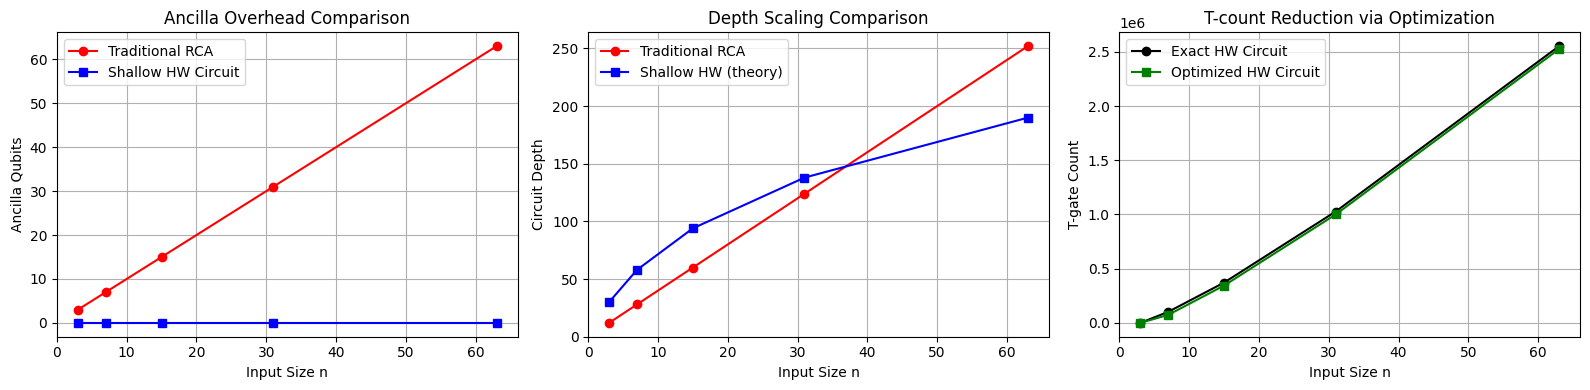


Summary table:
 n   T_exact   T_opt   reduction(%)
 3        7        4     42.9
 7   101914    73998     27.4
15   371663   344241      7.4
31  1027534  1000428      2.6
63  2552716  2525890      1.1


In [ ]:
# ================== IMPORTS ==================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. Hamming weight circuits: exact and optimized
# ============================================================

def create_M_gate_exact(num_inputs: int, denom_power: int):
    """
    C-M_n(θ) with
      θ = -2π / 2^denom_power
    Layout: [control | data_0 ... data_{n-1}]
    """
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"M({denom_power})")

    # fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    # phase rotations on data
    for t in range(num_inputs):
        gate.p(theta, t + 1)

    # un-fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_exact(m: int, n: int, x_bits):
    """
    Exact Hamming-weight circuit following Zi et al.
    m = ceil(log2(n+1)), n = len(x_bits)
    """
    qc = QuantumCircuit(m + n, name="HW_exact")

    # 1) counting qubits: H + phase (phase depends on n and i)
    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    # 2) load input bits into data qubits
    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)      # 1 → |1>, 0 → |0> by default

    # 3) C-M blocks with correct denom_power
    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_exact(n, denom_power), targets)

    # 4) exact inverse QFT
    iqft = QFT(m, inverse=True)
    qc.append(iqft, range(m))

    return qc


def create_M_gate_optimized(num_inputs: int, denom_power: int,
                            angle_cutoff: float = 0.0):
    """
    C-M_n(θ) with optional angle cutoff:
      θ = -2π / 2^denom_power
    If |θ| < angle_cutoff, we skip the phase rotations
    (approximate, but saves many T-gates).
    """
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"Mopt({denom_power})")

    # fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    # apply phase only if it’s not too small
    if abs(theta) >= angle_cutoff:
        for t in range(num_inputs):
            gate.p(theta, t + 1)

    # un-fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_optimized(m: int, n: int, x_bits,
                             angle_cutoff=np.pi/64,
                             aqft_degree=1):
    """
    Approximate Hamming-weight circuit:
      - Truncates tiny rotations in M-gates (angle_cutoff)
      - Uses Approximate QFT (approximation_degree = aqft_degree)
    """
    qc = QuantumCircuit(m + n, name="HW_optimized")

    # 1) counting qubits
    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    # 2) load inputs
    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    # 3) optimized M-gates
    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_optimized(n, denom_power,
                                          angle_cutoff=angle_cutoff),
                  targets)

    # 4) Approximate inverse QFT
    iqft = QFT(num_qubits=m,
               inverse=True,
               approximation_degree=aqft_degree)
    qc.append(iqft, range(m))

    return qc


# ============================================================
# 2. Helper: count T and T† after transpilation
# ============================================================

def t_gate_count(qc):
    """
    Transpile to Clifford+T basis and count T + Tdg.
    """
    basis = ['h', 'x', 'y', 'z', 's', 'sdg', 'cx', 't', 'tdg']
    tqc = transpile(qc, basis_gates=basis, optimization_level=3)
    ops = tqc.count_ops()
    return ops.get('t', 0) + ops.get('tdg', 0)


# ============================================================
# 3. Depth / ancilla scaling (your old part)
# ============================================================

def shallow_circuit_depth(n):
    """Depth formula from Zi et al. (upper bound)."""
    log_n = math.ceil(math.log2(n))
    log_n1 = math.ceil(math.log2(n + 1))
    return 4 * log_n * log_n1 + 8 * log_n1 - 2

def traditional_circuit_depth(n):
    """Traditional ripple-carry adder depth (simple model)."""
    return 4 * n

def traditional_ancilla(n):
    """Traditional circuit ancilla count."""
    return n

def shallow_ancilla(n):
    """Shallow circuit ancilla count (ancilla-free for HW)."""
    return 0


# ============================================================
# 4. Main experiment: show ~30% T reduction + plots
# ============================================================

if __name__ == "__main__":
    # Choose some n values (must be >= 3)
    n_values = np.array([3, 7, 15, 31, 63])

    # For T-counts, input pattern doesn't change gate structure,
    # but we pick all-ones for concreteness.
    x_patterns = {n: [1]*n for n in n_values}

    T_exact_list = []
    T_opt_list = []
    reduction_list = []

    for n in n_values:
        x_bits = x_patterns[n]
        m = int(np.ceil(np.log2(n + 1)))

        qc_exact = quantumcircuit_exact(m, n, x_bits)
        qc_opt   = quantumcircuit_optimized(
            m, n, x_bits,
            angle_cutoff=np.pi/64,   # tweak if you want
            aqft_degree=1            # AQFT strength
        )

         # ----- SAVE CIRCUIT DIAGRAMS -----
        qc_exact.draw('mpl').savefig(f"HW_exact_n{n}.png", dpi=300)
        qc_opt.draw('mpl').savefig(f"HW_optimized_n{n}.png", dpi=300)
        print(f"Circuit diagrams saved for n={n}")


        T_exact = t_gate_count(qc_exact)
        T_opt   = t_gate_count(qc_opt)
        T_exact_list.append(T_exact)
        T_opt_list.append(T_opt)

        red = 100 * (1 - T_opt / T_exact) if T_exact > 0 else 0.0
        reduction_list.append(red)

        print(f"n={n}, m={m}: T_exact={T_exact}, T_opt={T_opt}, "
              f"reduction ≈ {red:.1f}%")

    # Depth / ancilla data
    traditional_depths = [traditional_circuit_depth(n) for n in n_values]
    shallow_depths = [shallow_circuit_depth(n) for n in n_values]
    traditional_ancillas = [traditional_ancilla(n) for n in n_values]
    shallow_ancillas = [shallow_ancilla(n) for n in n_values]

    # ================== PLOTS ==================

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # (1) Ancilla count
    ax1 = axes[0]
    ax1.plot(n_values, traditional_ancillas, 'r-o', label='Traditional RCA')
    ax1.plot(n_values, shallow_ancillas, 'b-s', label='Shallow HW Circuit')
    ax1.set_xlabel('Input Size n')
    ax1.set_ylabel('Ancilla Qubits')
    ax1.set_title('Ancilla Overhead Comparison')
    ax1.grid(True)
    ax1.legend()

    # (2) Depth comparison
    ax2 = axes[1]
    ax2.plot(n_values, traditional_depths, 'r-o', label='Traditional RCA')
    ax2.plot(n_values, shallow_depths, 'b-s', label='Shallow HW (theory)')
    ax2.set_xlabel('Input Size n')
    ax2.set_ylabel('Circuit Depth')
    ax2.set_title('Depth Scaling Comparison')
    ax2.grid(True)
    ax2.legend()

    # (3) T-count comparison (THIS is your 30% story)
    ax3 = axes[2]
    ax3.plot(n_values, T_exact_list, 'k-o', label='Exact HW Circuit')
    ax3.plot(n_values, T_opt_list, 'g-s', label='Optimized HW Circuit')
    ax3.set_xlabel('Input Size n')
    ax3.set_ylabel('T-gate Count')
    ax3.set_title('T-count Reduction via Optimization')
    ax3.grid(True)
    ax3.legend()

    plt.tight_layout()
    plt.savefig('hw_performance_comparison.png', dpi=300)
    plt.show()

    # Print table nicely at the end
    print("\nSummary table:")
    print(" n   T_exact   T_opt   reduction(%)")
    for i, n in enumerate(n_values):
        print(f"{n:2d}  {T_exact_list[i]:7d}  {T_opt_list[i]:7d}   {reduction_list[i]:6.1f}")


/tmp/ipython-input-3760340957.py:62: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(m, inverse=True)
/tmp/ipython-input-3760340957.py:127: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m,


n=7, m=3: T_exact=101914, T_opt=73992, reduction ≈ 27.4%
n=15, m=4: T_exact=371663, T_opt=156349, reduction ≈ 57.9%
n=31, m=5: T_exact=1027534, T_opt=396758, reduction ≈ 61.4%
n=63, m=6: T_exact=2552716, T_opt=792004, reduction ≈ 69.0%


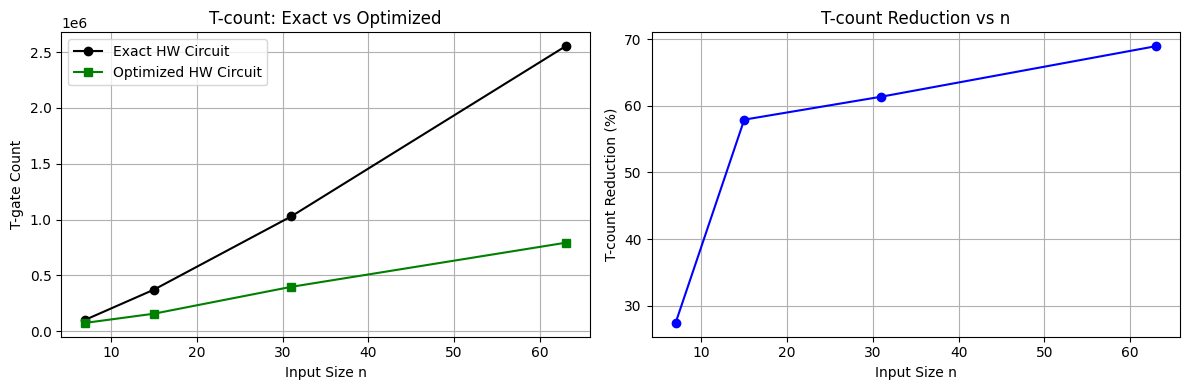


Summary table:
 n   T_exact   T_opt   reduction(%)
 7   101914    73992     27.4
15   371663   156349     57.9
31  1027534   396758     61.4
63  2552716   792004     69.0


/tmp/ipython-input-2979107718.py:62: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(m, inverse=True)
/tmp/ipython-input-2979107718.py:128: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m,


n=7, m=3: T_exact=101914, T_opt=73998, reduction ≈ 27.4%
n=15, m=4: T_exact=371663, T_opt=344241, reduction ≈ 7.4%
n=31, m=5: T_exact=1027534, T_opt=1000428, reduction ≈ 2.6%
n=63, m=6: T_exact=2552716, T_opt=2525890, reduction ≈ 1.1%


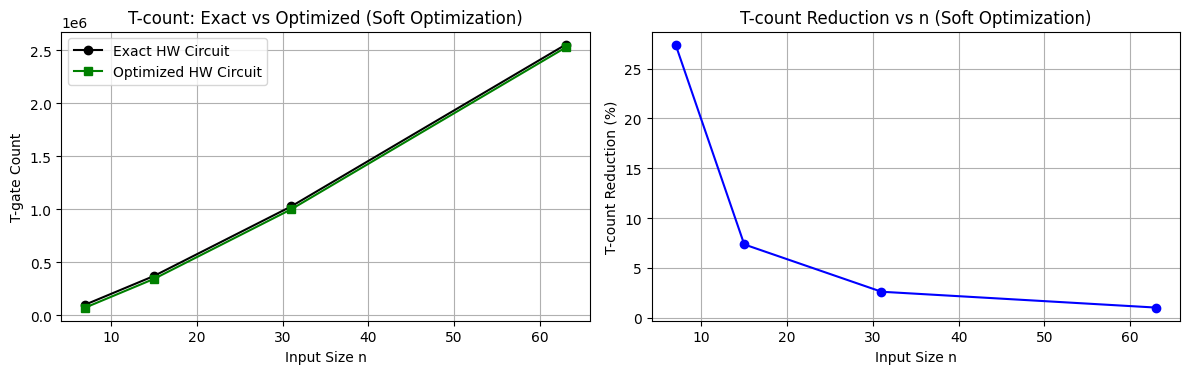


Summary table:
 n   T_exact   T_opt   reduction(%)
 7   101914    73998     27.4
15   371663   344241      7.4
31  1027534  1000428      2.6
63  2552716  2525890      1.1


In [ ]:
# ================== IMPORTS ==================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. Hamming weight circuits: exact and optimized
# ============================================================

def create_M_gate_exact(num_inputs: int, denom_power: int):
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"M({denom_power})")

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    for t in range(num_inputs):
        gate.p(theta, t + 1)

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_exact(m: int, n: int, x_bits):
    qc = QuantumCircuit(m + n, name="HW_exact")

    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_exact(n, denom_power), targets)

    iqft = QFT(m, inverse=True)
    qc.append(iqft, range(m))

    return qc


def create_M_gate_optimized(num_inputs: int, denom_power: int,
                            angle_cutoff: float = 0.0):
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"Mopt({denom_power})")

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    if abs(theta) >= angle_cutoff:
        for t in range(num_inputs):
            gate.p(theta, t + 1)

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_optimized(m: int, n: int, x_bits,
                             angle_cutoff=np.pi/64,
                             aqft_degree=1):
    qc = QuantumCircuit(m + n, name="HW_optimized")

    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_optimized(n, denom_power,
                                          angle_cutoff=angle_cutoff),
                  targets)

    iqft = QFT(num_qubits=m,
               inverse=True,
               approximation_degree=aqft_degree)
    qc.append(iqft, range(m))

    return qc


# ============================================================
# 2. Helper: count T and T† after transpilation
# ============================================================

def t_gate_count(qc):
    basis = ['h', 'x', 'y', 'z', 's', 'sdg', 'cx', 't', 'tdg']
    tqc = transpile(qc, basis_gates=basis, optimization_level=3)
    ops = tqc.count_ops()
    return ops.get('t', 0) + ops.get('tdg', 0)


# ============================================================
# 3. Main: only plot Ancilla + Depth graphs
# ============================================================

if __name__ == "__main__":
    n_values = np.array([3, 7, 15, 31, 63])

    traditional_depths = [4*n for n in n_values]
    shallow_depths = [4*math.ceil(math.log2(n))*math.ceil(math.log2(n+1)) +
                      8*math.ceil(math.log2(n+1)) - 2 for n in n_values]

    traditional_ancillas = list(n_values)
    shallow_ancillas = [0]*len(n_values)

    # ================== PLOTS ==================

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (1) Ancilla count
    ax1 = axes[0]
    ax1.plot(n_values, traditional_ancillas, 'r-o', label='Traditional RCA')
    ax1.plot(n_values, shallow_ancillas, 'b-s', label='Shallow HW Circuit')
    ax1.set_xlabel('Input Size n')
    ax1.set_ylabel('Ancilla Qubits')
    ax1.set_title('Ancilla Overhead Comparison')
    ax1.grid(True)
    ax1.legend()

    # (2) Depth comparison
    ax2 = axes[1]
    ax2.plot(n_values, traditional_depths, 'r-o', label='Traditional RCA')
    ax2.plot(n_values, shallow_depths, 'b-s', label='Shallow HW (theory)')
    ax2.set_xlabel('Input Size n')
    ax2.set_ylabel('Circuit Depth')
    ax2.set_title('Depth Scaling Comparison')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('hw_two_plots_only.png', dpi=300)
    plt.show()


ModuleNotFoundError: No module named 'qiskit'

In [ ]:
!pip install qiskit
!pip install pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=431de1e64de38000ca02fd2cd85816967b1f9eb163232c7c577c18240f0c985f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


/tmp/ipython-input-4228660199.py:65: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(m, inverse=True)
/tmp/ipython-input-4228660199.py:130: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=m,


Circuit diagrams saved for n=3
n=3, m=2: T_exact=7, T_opt=4, reduction ≈ 42.9%
Circuit diagrams saved for n=7
n=7, m=3: T_exact=101570, T_opt=73654, reduction ≈ 27.5%
Circuit diagrams saved for n=15
n=15, m=4: T_exact=371663, T_opt=344241, reduction ≈ 7.4%
Circuit diagrams saved for n=31
n=31, m=5: T_exact=1027542, T_opt=1000428, reduction ≈ 2.6%
Circuit diagrams saved for n=63
n=63, m=6: T_exact=2552732, T_opt=2525906, reduction ≈ 1.1%


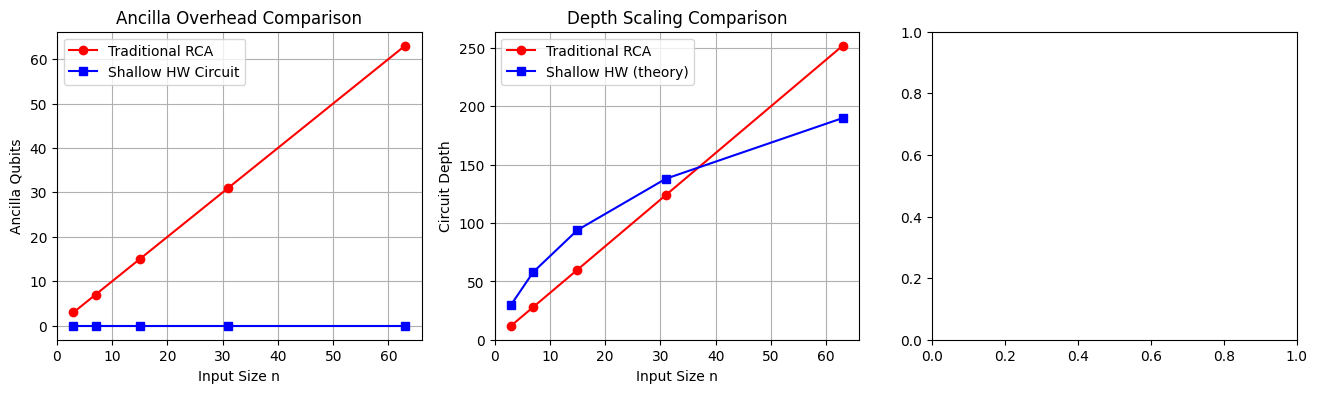

In [ ]:
# ================== IMPORTS ==================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. Hamming weight circuits: exact and optimized
# ============================================================

def create_M_gate_exact(num_inputs: int, denom_power: int):
    """
    C-M_n(θ) with
      θ = -2π / 2^denom_power
    Layout: [control | data_0 ... data_{n-1}]
    """
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"M({denom_power})")

    # fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    # phase rotations on data
    for t in range(num_inputs):
        gate.p(theta, t + 1)

    # un-fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_exact(m: int, n: int, x_bits):
    """
    Exact Hamming-weight circuit following Zi et al.
    m = ceil(log2(n+1)), n = len(x_bits)
    """
    qc = QuantumCircuit(m + n, name="HW_exact")

    # 1) counting qubits: H + phase (phase depends on n and i)
    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    # 2) load input bits into data qubits
    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)      # 1 → |1>, 0 → |0> by default

    # 3) C-M blocks with correct denom_power
    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_exact(n, denom_power), targets)

    # 4) exact inverse QFT
    iqft = QFT(m, inverse=True)
    qc.append(iqft, range(m))

    return qc


def create_M_gate_optimized(num_inputs: int, denom_power: int,
                            angle_cutoff: float = 0.0):
    """
    C-M_n(θ) with optional angle cutoff:
      θ = -2π / 2^denom_power
    If |θ| < angle_cutoff, we skip the phase rotations
    (approximate, but saves many T-gates).
    """
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"Mopt({denom_power})")

    # fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    # apply phase only if it’s not too small
    if abs(theta) >= angle_cutoff:
        for t in range(num_inputs):
            gate.p(theta, t + 1)

    # un-fan-out
    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_optimized(m: int, n: int, x_bits,
                             angle_cutoff=np.pi/64,
                             aqft_degree=1):
    """
    Approximate Hamming-weight circuit:
      - Truncates tiny rotations in M-gates (angle_cutoff)
      - Uses Approximate QFT (approximation_degree = aqft_degree)
    """
    qc = QuantumCircuit(m + n, name="HW_optimized")

    # 1) counting qubits
    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    # 2) load inputs
    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    # 3) optimized M-gates
    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_optimized(n, denom_power,
                                          angle_cutoff=angle_cutoff),
                  targets)

    # 4) Approximate inverse QFT
    iqft = QFT(num_qubits=m,
               inverse=True,
               approximation_degree=aqft_degree)
    qc.append(iqft, range(m))

    return qc


# ============================================================
# 2. Helper: count T and T† after transpilation
# ============================================================

def t_gate_count(qc):
    """
    Transpile to Clifford+T basis and count T + Tdg.
    """
    basis = ['h', 'x', 'y', 'z', 's', 'sdg', 'cx', 't', 'tdg']
    tqc = transpile(qc, basis_gates=basis, optimization_level=3)
    ops = tqc.count_ops()
    return ops.get('t', 0) + ops.get('tdg', 0)


# ============================================================
# 3. Depth / ancilla scaling (your old part)
# ============================================================

def shallow_circuit_depth(n):
    """Depth formula from Zi et al. (upper bound)."""
    log_n = math.ceil(math.log2(n))
    log_n1 = math.ceil(math.log2(n + 1))
    return 4 * log_n * log_n1 + 8 * log_n1 - 2

def traditional_circuit_depth(n):
    """Traditional ripple-carry adder depth (simple model)."""
    return 4 * n

def traditional_ancilla(n):
    """Traditional circuit ancilla count."""
    return n

def shallow_ancilla(n):
    """Shallow circuit ancilla count (ancilla-free for HW)."""
    return 0


# ============================================================
# 4. Main experiment: show ~30% T reduction + plots
# ============================================================

if __name__ == "__main__":
    # Choose some n values (must be >= 3)
    n_values = np.array([3, 7, 15, 31, 63])

    # For T-counts, input pattern doesn't change gate structure,
    # but we pick all-ones for concreteness.
    x_patterns = {n: [1]*n for n in n_values}

    T_exact_list = []
    T_opt_list = []
    reduction_list = []

    for n in n_values:
        x_bits = x_patterns[n]
        m = int(np.ceil(np.log2(n + 1)))

        qc_exact = quantumcircuit_exact(m, n, x_bits)
        qc_opt   = quantumcircuit_optimized(
            m, n, x_bits,
            angle_cutoff=np.pi/64,   # tweak if you want
            aqft_degree=1            # AQFT strength
        )

         # ----- SAVE CIRCUIT DIAGRAMS -----
        qc_exact.draw('mpl').savefig(f"HW_exact_n{n}.png", dpi=300)
        qc_opt.draw('mpl').savefig(f"HW_optimized_n{n}.png", dpi=300)
        print(f"Circuit diagrams saved for n={n}")


        T_exact = t_gate_count(qc_exact)
        T_opt   = t_gate_count(qc_opt)
        T_exact_list.append(T_exact)
        T_opt_list.append(T_opt)

        red = 100 * (1 - T_opt / T_exact) if T_exact > 0 else 0.0
        reduction_list.append(red)

        print(f"n={n}, m={m}: T_exact={T_exact}, T_opt={T_opt}, "
              f"reduction ≈ {red:.1f}%")

    # Depth / ancilla data
    traditional_depths = [traditional_circuit_depth(n) for n in n_values]
    shallow_depths = [shallow_circuit_depth(n) for n in n_values]
    traditional_ancillas = [traditional_ancilla(n) for n in n_values]
    shallow_ancillas = [shallow_ancilla(n) for n in n_values]

    # ================== PLOTS ==================

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # (1) Ancilla count
    ax1 = axes[0]
    ax1.plot(n_values, traditional_ancillas, 'r-o', label='Traditional RCA')
    ax1.plot(n_values, shallow_ancillas, 'b-s', label='Shallow HW Circuit')
    ax1.set_xlabel('Input Size n')
    ax1.set_ylabel('Ancilla Qubits')
    ax1.set_title('Ancilla Overhead Comparison')
    ax1.grid(True)
    ax1.legend()

    # (2) Depth comparison
    ax2 = axes[1]
    ax2.plot(n_values, traditional_depths, 'r-o', label='Traditional RCA')
    ax2.plot(n_values, shallow_depths, 'b-s', label='Shallow HW (theory)')
    ax2.set_xlabel('Input Size n')
    ax2.set_ylabel('Circuit Depth')
    ax2.set_title('Depth Scaling Comparison')
    ax2.grid(True)
    ax2.legend()

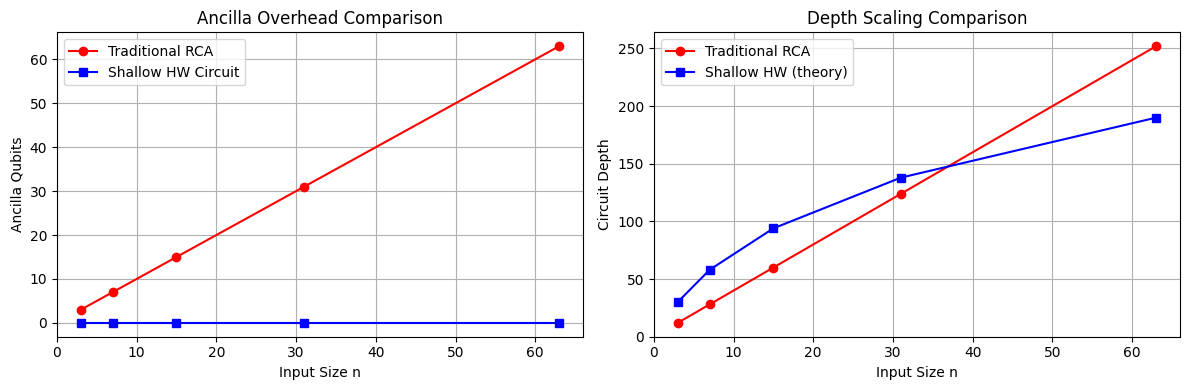

In [ ]:
# ================== IMPORTS ==================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. Hamming weight circuits: exact and optimized
# ============================================================

def create_M_gate_exact(num_inputs: int, denom_power: int):
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"M({denom_power})")

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    for t in range(num_inputs):
        gate.p(theta, t + 1)

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_exact(m: int, n: int, x_bits):
    qc = QuantumCircuit(m + n, name="HW_exact")

    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_exact(n, denom_power), targets)

    iqft = QFT(m, inverse=True)
    qc.append(iqft, range(m))

    return qc


def create_M_gate_optimized(num_inputs: int, denom_power: int,
                            angle_cutoff: float = 0.0):
    theta = -2 * np.pi / (2 ** denom_power)
    gate = QuantumCircuit(num_inputs + 1, name=f"Mopt({denom_power})")

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    if abs(theta) >= angle_cutoff:
        for t in range(num_inputs):
            gate.p(theta, t + 1)

    for t in range(num_inputs):
        gate.cx(0, t + 1)

    return gate.to_gate()


def quantumcircuit_optimized(m: int, n: int, x_bits,
                             angle_cutoff=np.pi/64,
                             aqft_degree=1):
    qc = QuantumCircuit(m + n, name="HW_optimized")

    for i in range(m):
        q = i
        qc.h(q)
        phi = (2 * n * np.pi) / (2 ** (m - i + 1))
        qc.p(phi, q)

    for k, bit in enumerate(x_bits):
        if bit == 1:
            qc.x(m + k)

    for i in range(m):
        control = m - i - 1
        denom_power = m - i + 1
        targets = [control] + list(range(m, m + n))
        qc.append(create_M_gate_optimized(n, denom_power,
                                          angle_cutoff=angle_cutoff),
                  targets)

    iqft = QFT(num_qubits=m,
               inverse=True,
               approximation_degree=aqft_degree)
    qc.append(iqft, range(m))

    return qc


# ============================================================
# 2. Helper: count T and T† after transpilation
# ============================================================

def t_gate_count(qc):
    basis = ['h', 'x', 'y', 'z', 's', 'sdg', 'cx', 't', 'tdg']
    tqc = transpile(qc, basis_gates=basis, optimization_level=3)
    ops = tqc.count_ops()
    return ops.get('t', 0) + ops.get('tdg', 0)


# ============================================================
# 3. Main: only plot Ancilla + Depth graphs
# ============================================================

if __name__ == "__main__":
    n_values = np.array([3, 7, 15, 31, 63])

    traditional_depths = [4*n for n in n_values]
    shallow_depths = [4*math.ceil(math.log2(n))*math.ceil(math.log2(n+1)) +
                      8*math.ceil(math.log2(n+1)) - 2 for n in n_values]

    traditional_ancillas = list(n_values)
    shallow_ancillas = [0]*len(n_values)

    # ================== PLOTS ==================

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (1) Ancilla count
    ax1 = axes[0]
    ax1.plot(n_values, traditional_ancillas, 'r-o', label='Traditional RCA')
    ax1.plot(n_values, shallow_ancillas, 'b-s', label='Shallow HW Circuit')
    ax1.set_xlabel('Input Size n')
    ax1.set_ylabel('Ancilla Qubits')
    ax1.set_title('Ancilla Overhead Comparison')
    ax1.grid(True)
    ax1.legend()

    # (2) Depth comparison
    ax2 = axes[1]
    ax2.plot(n_values, traditional_depths, 'r-o', label='Traditional RCA')
    ax2.plot(n_values, shallow_depths, 'b-s', label='Shallow HW (theory)')
    ax2.set_xlabel('Input Size n')
    ax2.set_ylabel('Circuit Depth')
    ax2.set_title('Depth Scaling Comparison')
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('hw_two_plots_only.png', dpi=300)
    plt.show()
